# 18. Continuing a calculation across a change of spin regime

An unpolarized run, a collinear one and a noncollinear one are three descriptions of the
same electrons, and the expensive part of all three — the charge density — is very nearly
the same object. This notebook takes a converged SCF and *starts another run from it* in a
different spin regime: non-magnetic → collinear, collinear → noncollinear, and spin-orbit
coupling switched on.

The headline numbers, all of them identities — the continued run reaches the **same**
self-consistent solution, because a starting guess is a guess and nothing else:

| case | fresh | continued | agreement |
|---|---|---|---|
| Si, `nspin` 2 → 4 | 5 iterations | **1** | 1e-9 Ry |
| bcc Fe, 2 → 4 with the moment rotated onto `x` | 25 | **1** | 2e-8 Ry |
| bcc Fe, 1 → 2, magnetization seeded | 30 | 27 | 5e-9 Ry |
| Pt, scalar PAW → fully-relativistic PAW + `lspinorb` | 13 | **7** | 2e-10 Ry |

`run_scf(starting_from=result)` is the whole interface; `System.with_spin` builds the target
regime's `System` — with its k-points rebuilt, which is the half of the job that is not the
density.

The three regimes are three ways of writing the same pair, so a promotion is *decompose,
decide what $\mathbf m$ should be, recompose*:

$$(n_\uparrow, n_\downarrow)
\;\longleftrightarrow\;
\big(n,\ m_z\big)
\;\longleftrightarrow\;
\big(n,\ \mathbf m\big),
\qquad
n = n_\uparrow + n_\downarrow, \quad m_z = n_\uparrow - n_\downarrow$$

On a `Calculator` that is one call -- `calc.with_spin(...)` returns a new calculator in the
target regime carrying the converged state as a **starting guess**, not as an answer.

In [1]:
import dataclasses
import warnings

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import Calculation, continued_state, run_scf
from pypresso.scf.continuation import from_spin_components, spin_components
from pypresso.system import build_system

QE = "../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite"
PSEUDO = "../tests/data/pseudo"

def system_from(path, **changes):
    return dataclasses.replace(build_system(read_pw_input(path)), tstress=False, **changes)


## Silicon: the same electrons, written three ways

The two-atom cell with Gaussian smearing, so that a second spin channel has an occupation
scheme that can fill it unequally. `with_spin` produces the collinear and the noncollinear
`System`; nothing about the crystal changes.

In [2]:
si_pseudo = (read_upf(f"{PSEUDO}/Si.pz-vbc.UPF"),)
si_calc = Calculator(system_from(f"{QE}/pw_scf/scf.in", occupations="smearing",
                                 smearing="gaussian", degauss=0.02),
                     si_pseudo, announce=False, conv_thr=1e-8)

# `Calculator.with_spin` is `System.with_spin` plus the seed: a new calculator in
# the target regime, with an empty cache and the parent's state as its guess.
collinear_calc = si_calc.with_spin(2, starting_magnetization=(0.3,))
spinor_calc = collinear_calc.with_spin(4, starting_magnetization=(0.0,))

silicon, collinear, spinor = (si_calc.system, collinear_calc.system,
                              spinor_calc.system)
print(f"nspin = 1: {silicon.kpoints.nk} k-points, weights summing to "
      f"{float(np.sum(silicon.kpoints.weights)):.1f}")
print(f"nspin = 2: {collinear.kpoints.nk} k-points, weights summing to "
      f"{float(np.sum(collinear.kpoints.weights)):.1f}   <- degspin dropped")
print(f"nspin = 4: {spinor.kpoints.nk} k-points, nspin_mag = {spinor.nspin_mag}, "
      f"npol = {spinor.npol}")

nspin = 1: 2 k-points, weights summing to 2.0
nspin = 2: 2 k-points, weights summing to 1.0   <- degspin dropped
nspin = 4: 2 k-points, nspin_mag = 1, npol = 2


In [3]:
si1 = si_calc.get_scf()

# Continued: the derived calculators already carry the seed, so this is one call.
si2_cont = collinear_calc.get_scf()
si4_cont = spinor_calc.get_scf()

# Fresh: the same systems with no seed at all, which is `starting_from=None`.
si2_fresh = collinear_calc.get_scf(starting_from=None)
si4_fresh = spinor_calc.get_scf(starting_from=None)

for name, result in [("nspin=1", si1), ("nspin=2 from atoms", si2_fresh),
                     ("nspin=2 continued", si2_cont), ("nspin=4 from atoms", si4_fresh),
                     ("nspin=4 continued", si4_cont)]:
    print(f"{name:22s} {result.total_energy:15.9f} Ry   {result.iterations:2d} iterations")
print(f"\n2 -> 4 continued vs fresh: {si4_cont.total_energy - si4_fresh.total_energy:+.1e} Ry")

nspin=1                  -15.794495570 Ry    5 iterations
nspin=2 from atoms       -15.794495568 Ry    5 iterations
nspin=2 continued        -15.794495568 Ry    5 iterations
nspin=4 from atoms       -15.794495570 Ry    5 iterations
nspin=4 continued        -15.794495570 Ry    5 iterations

2 -> 4 continued vs fresh: +0.0e+00 Ry


Silicon is not magnetic, so the seeded moment decays and all five runs are the same
answer — which is the point: the regime is a *description*, and the continuation does not
move the number. What it moves is the iteration count, and the noncollinear run converges on
the state it was handed.

## bcc iron: a moment that rotates, and one that has to be found

The interesting cases need a magnet. `pw_noncolin/noncolin.in` is QE's bcc iron with
`angle1 = 90`, which points the moment along `x`. Three runs of the same cell: non-magnetic,
collinear, and noncollinear.

In [4]:
iron_spinor = system_from(f"{QE}/pw_noncolin/noncolin.in")
fe_pseudo = (read_upf(f"{PSEUDO}/Fe.pz-nd-rrkjus.UPF"),)
iron_collinear = iron_spinor.with_spin(2)
iron_plain = iron_spinor.with_spin(1, starting_magnetization=(0.0,))

fe1 = run_scf(iron_plain, fe_pseudo, conv_thr=1e-8, mixing_beta=0.2)
fe2 = run_scf(iron_collinear, fe_pseudo, conv_thr=1e-8, mixing_beta=0.2)
print(f"non-magnetic  {fe1.total_energy:12.8f} Ry  {fe1.iterations:2d} iterations")
print(f"collinear     {fe2.total_energy:12.8f} Ry  {fe2.iterations:2d} iterations, "
      f"m = {fe2.magnetization:.4f} mu_B")
print(f"\nmagnetic stabilisation energy: {fe2.total_energy - fe1.total_energy:.6f} Ry")

non-magnetic  -55.67804951 Ry  16 iterations
collinear     -55.69968433 Ry  30 iterations, m = 3.1751 mu_B

magnetic stabilisation energy: -0.021635 Ry


In [5]:
fe4_fresh = run_scf(iron_spinor, fe_pseudo, conv_thr=1e-8, mixing_beta=0.2)
fe4_cont = run_scf(iron_spinor, fe_pseudo, conv_thr=1e-8, mixing_beta=0.2,
                   starting_from=fe2)
print(f"noncollinear from atoms   {fe4_fresh.total_energy:12.8f} Ry  "
      f"{fe4_fresh.iterations:2d} iterations")
print(f"noncollinear continued    {fe4_cont.total_energy:12.8f} Ry  "
      f"{fe4_cont.iterations:2d} iteration")
print(f"difference: {fe4_cont.total_energy - fe4_fresh.total_energy:+.1e} Ry")
print("\nm (mu_B):  collinear |m| = %.4f  ->  noncollinear (%.4f, %.4f, %.4f)"
      % ((fe2.magnetization,) + tuple(fe4_cont.magnetization_vector)))

noncollinear from atoms   -55.69968432 Ry  25 iterations
noncollinear continued    -55.69968430 Ry   1 iteration
difference: +2.0e-08 Ry

m (mu_B):  collinear |m| = 3.1751  ->  noncollinear (3.1755, 0.0000, -0.0000)


The collinear run knows only `|m|`; the continuation puts that number on the axis the
target's input asks for. That rotation is the only thing the promotion does here, and the
noncollinear run then converges in **one** iteration on the state it was handed.

Now the other direction — non-magnetic → collinear, where the magnetization is not carried
but *seeded*, and where the saving is small for a reason worth seeing.

In [6]:
fe2_cont = run_scf(iron_collinear, fe_pseudo, conv_thr=1e-8, mixing_beta=0.2,
                   starting_from=fe1)
# ... and the same continuation with the magnetization deliberately not seeded.
target = Calculation(iron_collinear, fe_pseudo)
unseeded = continued_state(fe1, target, magnetization="none")
print(unseeded.description)
fe2_flat = run_scf(iron_collinear, fe_pseudo, calculation=target, conv_thr=1e-8,
                   mixing_beta=0.2, starting_from=unseeded)
print(f"seeded    {fe2_cont.total_energy:12.8f} Ry  {fe2_cont.iterations:2d} iterations, "
      f"m = {fe2_cont.magnetization:.4f} mu_B")
print(f"unseeded  {fe2_flat.total_energy:12.8f} Ry  {fe2_flat.iterations:2d} iterations, "
      f"m = {fe2_flat.magnetization:.4f} mu_B   <- back to the non-magnetic solution")

nspin_mag 1 -> 2, magnetization left at zero, wavefunctions carried


seeded    -55.69968433 Ry  27 iterations, m = 3.1770 mu_B
unseeded  -55.67804951 Ry   2 iterations, m = 0.0000 mu_B   <- back to the non-magnetic solution


**That second run is the trap the whole module is shaped around.** Nothing in the SCF
breaks spin symmetry on its own: hand a collinear run two identical channels and it converges
— reporting convergence, because it did converge — straight back to the state it came from,
which is a stationary point of the polarized functional and not its minimum. The
magnetization has to be put in by hand, exactly as `starting_magnetization` puts it into a
run started from the atoms. `magnetization="auto"` does that automatically when the source
has none to carry.

## The figure: where the iterations go

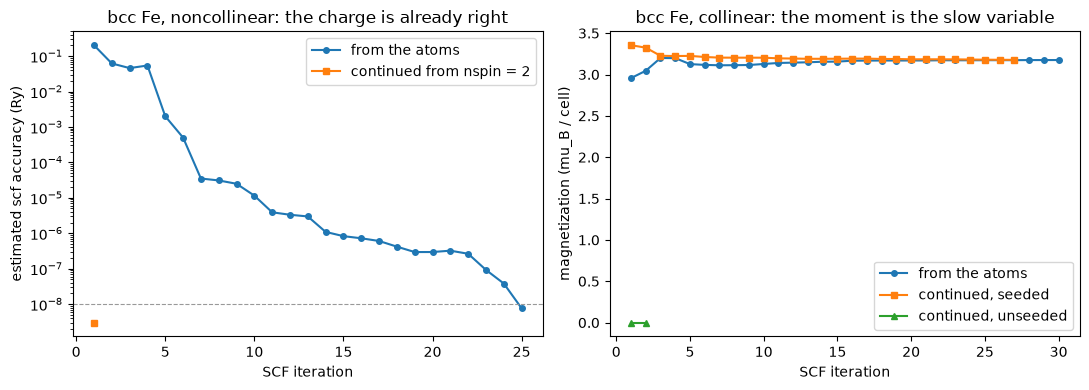

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for label, result, style in [("from the atoms", fe4_fresh, "-o"),
                             ("continued from nspin = 2", fe4_cont, "-s")]:
    steps = [entry["iteration"] for entry in result.history]
    accuracy = [entry["accuracy"] for entry in result.history]
    ax.semilogy(steps, accuracy, style, ms=4, label=label)
ax.axhline(1e-8, color="0.6", lw=0.8, ls="--")
ax.set_xlabel("SCF iteration"); ax.set_ylabel("estimated scf accuracy (Ry)")
ax.set_title("bcc Fe, noncollinear: the charge is already right"); ax.legend()

ax = axes[1]
for label, result, style in [("from the atoms", fe2, "-o"),
                             ("continued, seeded", fe2_cont, "-s"),
                             ("continued, unseeded", fe2_flat, "-^")]:
    steps = [entry["iteration"] for entry in result.history]
    moment = [entry.get("magnetization", 0.0) for entry in result.history]
    ax.plot(steps, moment, style, ms=4, label=label)
ax.set_xlabel("SCF iteration"); ax.set_ylabel("magnetization (mu_B / cell)")
ax.set_title("bcc Fe, collinear: the moment is the slow variable"); ax.legend()
fig.tight_layout()

Left: the continued noncollinear run starts three orders of magnitude closer than the
atomic guess and is done in one step. Right: the same continuation across 1 → 2 saves three
iterations out of thirty, because what it carries — the charge — was never the hard part;
the *moment* is, and the non-magnetic run has none of it. The flat line is the unseeded run
sitting on the symmetric solution.

## How it works: one representation, and every direction is the same code

The three regimes are three ways of writing the same pair `(n(r), m(r))` — `[n]`,
`[n_up, n_dw]` and `[n, m_x, m_y, m_z]`. So a promotion is *decompose, decide what `m` should
be, recompose*, and a demotion is the same function read the other way. The collinear moment
is placed on `z`, which is what makes the collinear → noncollinear step a rotation rather
than a reinterpretation.

In [8]:
cell_volume = float(iron_collinear.cell.volume)

def integrate(field):
    # int f(r) dr over the cell, from its values on the FFT grid
    field = np.asarray(field)
    return float(np.sum(field)) * cell_volume / field.size

charge, moment = spin_components(fe2.density, fe2.nspin_mag)      # [n_up, n_dw]
print(f"collinear    int n = {integrate(charge):8.4f}   int m_z = {integrate(moment[2]):7.4f}")

# What the promotion does: the same charge, the moment turned onto the target's axis.
zero = np.zeros_like(moment[2])
rotated = np.stack([moment[2], zero, zero])          # z -> x, which is angle1 = 90
promoted = from_spin_components(charge, rotated, 4)              # [n, m_x, m_y, m_z]
print(f"promoted     int n = {integrate(promoted[0]):8.4f}   int m_x = {integrate(promoted[1]):7.4f}")

_, vector = spin_components(fe4_cont.density, 4)
print("converged    int m = (%.4f, %.4f, %.4f)" % tuple(integrate(c) for c in vector))

collinear    int n =   8.0000   int m_z =  3.1751
promoted     int n =   8.0000   int m_x =  3.1751
converged    int m = (3.1755, -0.0000, 0.0000)


## Switching spin-orbit coupling on

For an ultrasoft or PAW dataset, "spin-orbit off" with the *same* file needs QE's
`average_pp`, which QE itself refuses for ultrasoft (`PW/src/average_pp.f90`). So the toggle
is a change of *dataset*: platinum with a scalar-relativistic PAW pseudopotential, then with
the fully-relativistic one and `lspinorb = .true.`. The projector counts differ, so `becsum`
is re-seeded from the target's own dataset — with a warning saying so — and the density is
what carries.

In [9]:
pt_scalar = system_from("../tests/data/qe/pt-paw-scalar.in")
pt_spinor = system_from(f"{QE}/pw_spinorbit/spinorbit-paw.in")
pt_sr = (read_upf(f"{PSEUDO}/Pt.pbe-n-kjpaw_psl.0.1.UPF"),)
pt_fr = (read_upf(f"{PSEUDO}/Pt.rel-pbe-n-kjpaw_psl.0.1.UPF"),)

pt1 = run_scf(pt_scalar, pt_sr, conv_thr=1e-9)
pt_fresh = run_scf(pt_spinor, pt_fr, conv_thr=1e-9)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # "a different pseudopotential" -- expected here
    pt_cont = run_scf(pt_spinor, pt_fr, conv_thr=1e-9, starting_from=pt1)

print(f"scalar, nspin = 1        {pt1.total_energy:14.8f} Ry  {pt1.iterations:2d} iterations")
print(f"spin-orbit from atoms    {pt_fresh.total_energy:14.8f} Ry  {pt_fresh.iterations:2d} iterations")
print(f"spin-orbit continued     {pt_cont.total_energy:14.8f} Ry  {pt_cont.iterations:2d} iterations")
print(f"difference: {pt_cont.total_energy - pt_fresh.total_energy:+.1e} Ry")

scalar, nspin = 1         -747.28843798 Ry  12 iterations
spin-orbit from atoms     -753.34269162 Ry  13 iterations
spin-orbit continued      -753.34269162 Ry   7 iterations
difference: +1.9e-10 Ry


---

**Where the detail is.** `PLAN.md` P23 — the `(n, m)` representation, the seeding rule and
its tolerance, what `pw.x` has of this (`startingpot = 'file'` zero-fills the spin components
a file does not have, and `nc_magnetization_from_lsda` rotates onto `angle1(1)` only inside
the force-theorem path), why the wavefunctions cross as a *span* rather than as
wavefunctions, and everything refused by name. The code is
`pypresso/scf/continuation.py` and `System.with_spin`; the tests are
`tests/unit/test_continuation_machinery.py` and `tests/regression/test_continuation.py`.